# Siamese Neural Networks for One-Shot Image Recognition

## Project Introduction:

This project reproduces and explores the Siamese Neural Network model presented in the paper “Siamese Neural Networks for One-shot Image Recognition”. The goal of the project is to understand how a neural network can learn to recognize new visual categories using only a single example per class, a setting known as one-shot learning.

Unlike standard classification models, which require many labeled examples per class and learn fixed class boundaries, Siamese networks learn a similarity function between pairs of images. The model maps each image into a high-dimensional embedding space and determines whether two images belong to the same class by measuring the similarity between their embeddings. This approach allows the model to generalize to completely unseen classes without retraining.

The project uses the Omniglot dataset, which contains handwritten characters from many different alphabets and is commonly used as a benchmark for one-shot learning. The network is trained on image pairs sampled from a background set and evaluated using an episodic one-shot classification protocol that closely follows the methodology described in the original paper.


### Imports

In [ ]:
# =========================
# Core Python utilities
# =========================
import os                     # File system operations
import random                 # Random sampling utilities
from pathlib import Path      # Object-oriented path handling

# =========================
# Numerical computation and plotting
# =========================
import numpy as np            # Numerical arrays and math operations
import matplotlib.pyplot as plt  # Visualization utilities

# =========================
# PyTorch core modules
# =========================
import torch                  # Core PyTorch library
import torch.nn as nn         # Neural network layers and modules
import torch.nn.functional as F  # Functional operations (activations, losses)
import torch.optim as optim   # Optimization algorithms

# =========================
# PyTorch data utilities
# =========================
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset handling
from torchvision import datasets, transforms                   # Datasets and preprocessing

# =========================
# Image processing
# =========================
from PIL import Image         # Image loading and manipulation

# =========================
# Reproducibility
# =========================
torch.manual_seed(42)         # Fix PyTorch random seed
np.random.seed(42)            # Fix NumPy random seed
random.seed(42)               # Fix Python random seed

# =========================
# Device configuration
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Timing utilities
# =========================
import time                   # Measure training and evaluation runtime


Using device: cuda


## Siamese Training Dataset

Here we define the dataset for training the Siamese network. The dataset is constructed from the Omniglot background split and is designed to generate image pairs dynamically. Each training sample consists of two images and a binary label indicating whether the two images belong to the same character class.

All images are first loaded into memory to avoid repeated disk access during training. The dataset maintains a mapping from each class label to the indices of images belonging to that class, enabling efficient sampling of positive pairs (same class) and negative pairs (different classes). During training, pairs are sampled with equal probability to ensure a balanced learning signal.

In [ ]:
class SiameseOmniglotPairs(Dataset):
    def __init__(self, root, background=True, transform=None):
        # Load Omniglot background dataset
        base_dataset = datasets.Omniglot(
            root=root,
            background=background,
            download=True,
            transform=transform
        )

        # Store all images and labels in memory
        self.images = []
        self.labels = []

        for img, label in base_dataset:
            self.images.append(img)
            self.labels.append(label)

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

        # Build mapping from class label to image indices
        self.class_to_indices = {}
        for i, label in enumerate(self.labels.tolist()):
            self.class_to_indices.setdefault(label, []).append(i)

        self.classes = list(self.class_to_indices.keys())

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # First image and label
        img1 = self.images[idx]
        label1 = self.labels[idx].item()

        # Sample positive or negative pair
        if random.random() < 0.5:
            idx2 = random.choice(self.class_to_indices[label1])
            img2 = self.images[idx2]
            y = 1.0
        else:
            label2 = random.choice([c for c in self.classes if c != label1])
            idx2 = random.choice(self.class_to_indices[label2])
            img2 = self.images[idx2]
            y = 0.0

        return img1, img2, torch.tensor([y], dtype=torch.float32)


## One-Shot Evaluation Dataset

Here we define the dataset for one-shot evaluation. Each dataset item represents a complete one-shot classification task, also called an episode. In each episode, a fixed number of classes is sampled, one support image is selected for each class, and a query image is chosen from one of those classes.

The dataset uses the Omniglot evaluation split to ensure that no characters seen during training appear during testing. This episodic structure closely follows the evaluation protocol described in the original paper and allows the model's ability to generalize to unseen classes to be measured accurately.

In [ ]:
class OmniglotOneShot(Dataset):
    def __init__(self, root,n_way=20,transform=None, tasks=400, use_all_queries=False):
        """
        Args:
            tasks (int): number of one-shot episodes (used if use_all_queries=False)
            use_all_queries (bool):
                False → paper-style random episodes (default)
                True  → each test image is used exactly once as query
        """
        self.dataset = datasets.Omniglot(
            root=root,
            background=False,   # evaluation alphabets
            download=True,
            transform=transform
        )

        self.n_way = n_way
        self.use_all_queries = use_all_queries

        # Map class → image indices
        self.class_to_indices = {}
        for i, (_, label) in enumerate(self.dataset):
            self.class_to_indices.setdefault(label, []).append(i)

        self.classes = list(self.class_to_indices.keys())

        # Dataset length logic
        if self.use_all_queries:
            self.tasks = len(self.dataset)
        else:
            self.tasks = tasks

    def __len__(self):
        return self.tasks

    def __getitem__(self, idx):
        # ==================================================
        # MODE 1: Every image is a query (deterministic)
        # ==================================================
        if self.use_all_queries:
            query, query_class = self.dataset[idx]

            other_classes = random.sample(
                [c for c in self.classes if c != query_class],
                self.n_way - 1
            )

            selected_classes = [query_class] + other_classes
            random.shuffle(selected_classes)

        # ==================================================
        # MODE 2: Paper-style random episode
        # ==================================================
        else:
            selected_classes = random.sample(self.classes, self.n_way)
            query_class = random.choice(selected_classes)
            q_idx = random.choice(self.class_to_indices[query_class])
            query, _ = self.dataset[q_idx]

        # ==================================================
        # Sample one support image per class
        # ==================================================
        supports = []
        for c in selected_classes:
            s_idx = random.choice(self.class_to_indices[c])
            img, _ = self.dataset[s_idx]
            supports.append(img)

        return (
            query,
            torch.stack(supports),
            torch.tensor(selected_classes, dtype=torch.long),
            torch.tensor(query_class, dtype=torch.long)
        )


## Custom Collation for One-Shot Episodes

Here we make a custom collation function for the one-shot evaluation DataLoader. Since each dataset item already represents a full episode, the default PyTorch collation behavior is unsuitable. The custom function ensures that each episode is treated as a single batch and that tensor dimensions are consistent for evaluation.

In [ ]:
def oneshot_collate_fn(batch):
    # Unpack single episode
    query, supports, support_labels, true_class = batch[0]

    # Ensure tensor types
    if isinstance(support_labels, list):
        support_labels = torch.tensor(support_labels, dtype=torch.long)
    if isinstance(true_class, list):
        true_class = torch.tensor(true_class, dtype=torch.long)

    # Add batch dimension
    return (
        query.unsqueeze(0),
        supports.unsqueeze(0),
        support_labels.unsqueeze(0),
        true_class.unsqueeze(0)
    )


## DataLoader Creation

Now we create the DataLoaders used for training, validation, and one-shot evaluation. The training dataset is split into training and validation subsets to support early stopping. Image preprocessing is applied consistently across all datasets. A custom collation function is used for the one-shot evaluation loader to preserve episodic structure.

In [ ]:
def create_dataloaders(
    root="./data",
    batch_size=128,
    n_way=20,
    val_tasks=320,
    num_workers=2
):
    # =========================
    # TRAIN TRANSFORM (with augmentation)
    # =========================
    train_transform = transforms.Compose([
        transforms.Resize((105, 105)),
        transforms.RandomAffine(
            degrees=(-10,10),
            translate=(0.3, 0.3),
            scale=(0.8, 1.2),
            shear=(-2,2)
        ),
        transforms.ToTensor()
    ])

    # =========================
    # VAL / TEST TRANSFORM
    # =========================
    test_transform = transforms.Compose([
        transforms.Resize((105, 105)),
        transforms.ToTensor()
    ])

    # =========================
    # TRAIN DATASET (PAIRWISE)
    # =========================
    train_dataset = SiameseOmniglotPairs(
        root=root,
        background=True,
        transform=train_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    # =========================
    # ONE-SHOT VALIDATION DATASET (NEW)
    # =========================
    val_one_shot_dataset = OmniglotOneShot(
        root=root,
        n_way=n_way,
        transform=test_transform,
        tasks=val_tasks,
        use_all_queries=False   # paper-style random episodes
    )

    val_one_shot_loader = DataLoader(
        val_one_shot_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=oneshot_collate_fn
    )

    # =========================
    # ONE-SHOT TEST DATASET (UNCHANGED)
    # =========================
    test_dataset = OmniglotOneShot(
        root=root,
        n_way=n_way,
        transform=test_transform,
        tasks=400,
        use_all_queries=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=oneshot_collate_fn
    )

    return train_loader, val_one_shot_loader, test_loader


## Dataset and DataLoader Initialization

This cell creates the training, validation, and test DataLoaders using the previously defined utility function..

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(
    root="./data",
    batch_size=128,
    n_way=20
)

print("Train pairs:", len(train_loader.dataset))
print("Val pairs:", len(val_loader.dataset))
print("One-shot tasks:", len(test_loader.dataset))


Train pairs: 19280
Val pairs: 320
One-shot tasks: 400


## Siamese Network Architecture

Here we create the Siamese neural network as the paper says. The network consists of two identical convolutional branches with shared weights, which map input images into a 4096-dimensional embedding space.

Let's dive deep into the network:

### High-level structure of the network

The Siamese network consists of two identical branches with shared weights. Each branch implements a function:

𝑓 ( 𝑥 ) : image → 𝑅 4096

The network can be divided into three conceptual parts:

1. Convolutional feature extractor

2. Fully connected embedding layer

3. Similarity computation head

#### **Convolutional layers**

**Input:**

Grayscale Omniglot image

Size: 105 × 105 × 1

**First convolution block:**

Conv2d(1 → 64, kernel=10)

ReLU

MaxPool(2)

**Second convolution block:**

Conv2d(64 → 128, kernel=7)

ReLU

MaxPool(2)

**Third convolution block:**

Conv2d(128 → 128, kernel=4)

ReLU

MaxPool(2)

**Fourth convolution block:**

Conv2d(128 → 256, kernel=4)

ReLU

### **Fully connected embedding layer:**
Linear(9216 → 4096)

Sigmoid


#### **Similarity computation:**
d = |embedding₁ − embedding₂|

score = sigmoid(α(d))







In [ ]:
class SiameseNeuralNetwork(nn.Module):
    def __init__(self):
      super(SiameseNeuralNetwork, self).__init__()

      # Convolutional feature extractor
      self.CNN1 = nn.Sequential(
          nn.Conv2d(in_channels=1,out_channels=64,kernel_size=10,stride=1,bias=True),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,stride=2),



          nn.Conv2d(in_channels=64,out_channels=128,kernel_size=7,stride=1,bias=True),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,stride=2),

          nn.Conv2d(in_channels=128,out_channels=128,kernel_size=4,stride=1,bias=True),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,stride=2),

          nn.Conv2d(in_channels=128,out_channels=256,kernel_size=4,stride=1,bias=True),
          nn.ReLU()

      )

      # Embedding layer
      self.fullyconnected = nn.Sequential(
          nn.Linear(in_features=9216,out_features=4096),
          nn.Sigmoid()
      )
      # Similarity scoring layer
      self.alpha  = nn.Linear(in_features=4096,out_features=1,bias=False)

    def forward_once(self, x):
        x = self.CNN1(x)
        x = x.view(x.size(0), -1)
        x = self.fullyconnected(x)
        return x

    def forward(self, x1, x2):
      output1 = self.forward_once(x1)

      output2 = self.forward_once(x2)

      d = torch.abs(output1 - output2)

      similarity = torch.sigmoid(self.alpha(d))

      return similarity


## Model Initialization and Optimization Setup

he Siamese network is trained as a binary classifier over image pairs, where the objective is to predict whether two input images belong to the same character class.

**Loss Function**

The paper defines a regularized binary cross-entropy objective. Given a minibatch of image pairs
( 𝑥 1( 𝑖 ) , 𝑥 2 ( 𝑖 ) ) with corresponding labels
𝑦 ( 𝑖 ) ∈ { 0 , 1 } the loss is formulated as:

𝐿 ( 𝑥 1 ( 𝑖 ) , 𝑥 2 ( 𝑖 ) ) = 𝑦 ( 𝑖 ) log 𝑝( 𝑥1(𝑖) , 𝑥2(𝑖) ) + ( 1 − 𝑦 ( 𝑖 ) ) log ⁡( 1 − 𝑝 ( 𝑥1(𝑖) , 𝑥2(𝑖) )  + 𝜆 ∥ 𝑤 ∥ 2 2


where 𝑝(𝑥1,𝑥2) denotes the predicted probability that the two images belong to the same class, and the final term represents L2 regularization on the network weights.
In our implementation, this objective is realized using binary cross-entropy loss combined with weight decay, which directly corresponds to the regularization term described in the paper.

**Optimization Method**

The authors optimize this objective using stochastic gradient descent (SGD) with momentum, where gradients from both branches of the Siamese network are accumulated due to shared weights. This additive gradient property arises naturally from weight tying and is handled automatically by modern deep learning frameworks.

Δw(T)=−ηj​∇w(T)+μj​Δw(T−1)

Although the paper allows for layer-wise learning rates, momentum values, and regularization strengths, we employ a single global learning rate and momentum value for simplicity. This preserves the optimization principle while reducing implementation complexity.

**Learning Schedule**

The paper specifies an exponential learning rate decay of 1% per epoch:

𝜂𝑗(𝑇)= 0.99 ⋅ 𝜂𝑗(𝑇−1)


This learning schedule is used to stabilize convergence and allow the network to refine the learned embedding space over time. We implement this decay using an exponential learning rate scheduler applied uniformly across all layers.

**Early Stopping**

Training is performed for a maximum of 200 epochs, while monitoring one-shot validation performance. Following the paper, training is stopped early if validation performance does not improve for 20 consecutive epochs, and the model parameters from the best epoch are retained.

Overall, this training configuration faithfully reproduces the optimization strategy described in the original work, with minor simplifications that do not alter the core learning dynamics of the Siamese network.

In [ ]:
# Initialize Siamese network and move to device
model = SiameseNeuralNetwork().to(device)

# Binary cross-entropy loss for similarity prediction
criterion = nn.BCELoss()

# Stochastic Gradient Descent with momentum and weight decay
optimizer = torch.optim.SGD(
    [
        # Convolutional backbone
        {
            "params": model.CNN1.parameters(),
            "lr": 0.005,
            "momentum": 0.5
        },

        # Embedding layer (9216 → 4096)
        {
            "params": model.fullyconnected.parameters(),
            "lr": 0.01,
            "momentum": 0.5
        },

        # Similarity layer (α)
        {
            "params": model.alpha.parameters(),
            "lr": 0.02,
            "momentum": 0.5
        },
    ],
    weight_decay=1e-4
)


# Exponential learning rate decay
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)


One Shot Validation

In [ ]:
def one_shot_validation(model, one_shot_loader, device, num_tasks=320):
    model.eval()
    correct = 0

    with torch.no_grad():
        loader_iter = iter(one_shot_loader)

        for _ in range(num_tasks):
            # UNPACK 4 VALUES (this fixes the error)
            query, supports, support_labels, true_class = next(loader_iter)

            # Shapes after collate:
            # query          : [1, 1, 105, 105]
            # supports       : [1, N, 1, 105, 105]
            # support_labels : [1, N]
            # true_class     : [1]

            query = query.to(device)
            supports = supports.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0)
            true_class = true_class.item()

            # Repeat query N times
            query_batch = query.repeat(supports.size(0), 1, 1, 1)

            # Similarity scores
            scores = model(query_batch, supports).squeeze()

            predicted_index = torch.argmax(scores).item()
            predicted_class = support_labels[predicted_index].item()

            if predicted_class == true_class:
                correct += 1

    accuracy = correct / num_tasks
    return 1.0 - accuracy


## Training Procedure

This cell defines the training procedure for the Siamese network. The model is trained for a fixed number of epochs, with each epoch consisting of a training phase and a validation phase. During training, image pairs are processed in batches, and model parameters are updated using backpropagation.

Validation loss is computed after each epoch to monitor generalization performance. Early stopping is applied to prevent overfitting by halting training when validation loss stops improving. The function also records training loss, validation loss, and epoch duration, enabling later analysis of convergence behavior and computational efficiency.

In [ ]:
def train(
    model,
    train_loader,
    one_shot_loader,
    epochs=200,
    patience=20,
    num_val_tasks=320
):
    history = {
        "train_loss": [],
        "one_shot_error": [],
        "epoch_time": []
    }

    best_error = float("inf")
    counter = 0

    # Momentum schedule (paper)
    start_momentum = 0.5
    final_momentum = 0.9

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        # =========================
        # Momentum annealing
        # =========================
        current_momentum = start_momentum + \
            (final_momentum - start_momentum) * (epoch / epochs)

        for param_group in optimizer.param_groups:
            param_group["momentum"] = current_momentum

        # =========================
        # Training phase (pairs)
        # =========================
        model.train()
        train_loss = 0.0

        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(x1, x2)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # =========================
        # One-shot validation
        # =========================
        val_error = one_shot_validation(
            model,
            one_shot_loader,
            device,
            num_tasks=num_val_tasks
        )

        # =========================
        # Learning rate decay
        # =========================
        scheduler.step()

        # =========================
        # Timing
        # =========================
        epoch_time = time.time() - epoch_start_time

        # =========================
        # Logging
        # =========================
        history["train_loss"].append(train_loss)
        history["one_shot_error"].append(val_error)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"One-shot Error: {val_error:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.5f} | "
            f"Momentum: {current_momentum:.3f} | "
            f"Time: {epoch_time:.2f}s"
        )

        # =========================
        # Early stopping (paper)
        # =========================
        if val_error < best_error:
            best_error = val_error
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered (one-shot error).")
                break

    total_time = time.time() - total_start_time
    return history, total_time


## One-Shot Evaluation

This cell defines the evaluation procedure for one-shot learning. The model is evaluated using episodic tasks, where each task consists of a query image and a support set containing one example per class. For each episode, the model computes similarity scores between the query and each support image and predicts the class corresponding to the highest similarity.

Overall accuracy is computed as the fraction of correctly classified episodes. The total evaluation time and average time per episode are also measured to assess inference efficiency.

In [ ]:
def evaluate_one_shot(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    # Measure evaluation time
    eval_start_time = time.time()

    with torch.no_grad():
        for query, supports, support_labels, true_class in test_loader:
            # Move query and supports to device
            query = query.to(device)
            supports = supports.squeeze(0).to(device)

            # Remove batch dimension from labels
            support_labels = support_labels.squeeze(0)
            true_class = true_class.item()

            # Compute similarity scores
            scores = []
            for i in range(supports.size(0)):
                sim = model(query, supports[i].unsqueeze(0))
                scores.append(sim.item())

            # Select class with maximum similarity
            pred_idx = int(np.argmax(scores))
            pred_class = support_labels[pred_idx].item()

            # Check correctness
            if pred_class == true_class:
                correct += 1

            total += 1

    eval_time = time.time() - eval_start_time
    accuracy = correct / total

    return {
        "accuracy": accuracy,
        "eval_time": eval_time,
        "avg_time_per_task": eval_time / total
    }


## Visualization of Training Pairs

In [ ]:
def show_training_pairs(dataset, num_examples=3):
    fig, axes = plt.subplots(num_examples, 2, figsize=(4, 2*num_examples))

    for i in range(num_examples):
        img1, img2, y = dataset[i]

        axes[i, 0].imshow(img1.squeeze(), cmap="gray")
        axes[i, 0].set_title("Image 1")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img2.squeeze(), cmap="gray")
        axes[i, 1].set_title(f"Image 2 | Same={int(y.item())}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


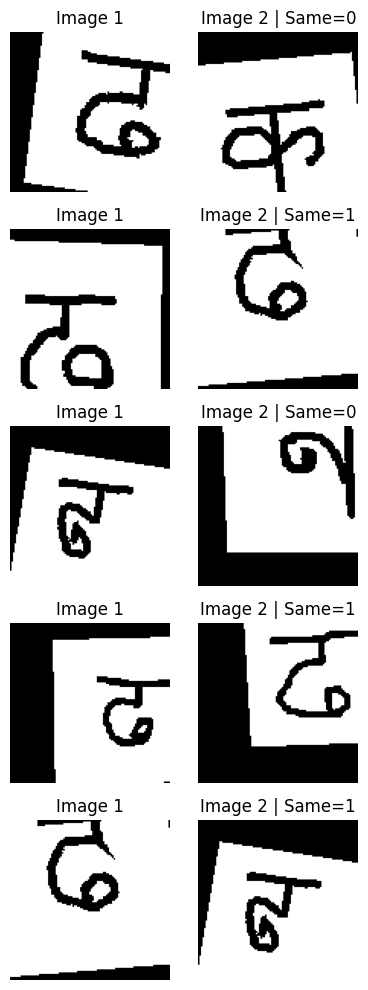

In [ ]:
show_training_pairs(train_loader.dataset, num_examples=5)


## Model Training

In [ ]:
history, total_train_time = train(
    model=model,
    train_loader=train_loader,
    one_shot_loader=val_loader,
    epochs=200,
    patience=9999
)

Epoch 001 | Train Loss: 0.6932 | One-shot Error: 0.9469 | LR: 0.00495 | Momentum: 0.500 | Time: 56.56s
Epoch 002 | Train Loss: 0.6931 | One-shot Error: 0.9031 | LR: 0.00490 | Momentum: 0.508 | Time: 56.51s
Epoch 003 | Train Loss: 0.6931 | One-shot Error: 0.8719 | LR: 0.00485 | Momentum: 0.516 | Time: 56.50s
Epoch 004 | Train Loss: 0.6931 | One-shot Error: 0.7937 | LR: 0.00480 | Momentum: 0.524 | Time: 56.59s
Epoch 005 | Train Loss: 0.6931 | One-shot Error: 0.7937 | LR: 0.00475 | Momentum: 0.532 | Time: 56.60s
Epoch 006 | Train Loss: 0.6930 | One-shot Error: 0.7219 | LR: 0.00471 | Momentum: 0.540 | Time: 56.44s
Epoch 007 | Train Loss: 0.6930 | One-shot Error: 0.6937 | LR: 0.00466 | Momentum: 0.548 | Time: 56.56s
Epoch 008 | Train Loss: 0.6930 | One-shot Error: 0.6500 | LR: 0.00461 | Momentum: 0.556 | Time: 56.62s
Epoch 009 | Train Loss: 0.6929 | One-shot Error: 0.6562 | LR: 0.00457 | Momentum: 0.564 | Time: 56.42s
Epoch 010 | Train Loss: 0.6929 | One-shot Error: 0.6594 | LR: 0.00452 | M

KeyboardInterrupt: 

## Final Evaluation and Results

In [ ]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

eval_results = evaluate_one_shot(model, test_loader)

print("\n===== FINAL RESULTS =====")
print(f"Total training time: {total_train_time:.2f}s")
print(f"Final accuracy: {eval_results['accuracy']:.4f}")
print(f"Evaluation time: {eval_results['eval_time']:.2f}s")
print(f"Avg time per task: {eval_results['avg_time_per_task']:.4f}s")

## Visualization of a One-Shot Classification Task

Here we visualize a single one-shot classification episode. The query image is shown alongside its support set, with the correct support image highlighted. This visualization provides an intuitive understanding of how one-shot learning operates and helps verify the correctness of the evaluation pipeline.

In [ ]:
def show_one_shot_task(dataset):
    query, supports, labels, true_class = dataset[0]

    n = supports.size(0)

    fig, axes = plt.subplots(1, n + 1, figsize=(2*(n+1), 3))

    # Query
    axes[0].imshow(query.squeeze(), cmap="gray")
    axes[0].set_title("Query", fontsize=12)
    axes[0].axis("off")

    # Supports
    for i in range(n):
        axes[i+1].imshow(supports[i].squeeze(), cmap="gray")

        # Highlight true class
        if labels[i].item() == true_class.item():
            axes[i+1].set_title("MATCH", color="green", fontsize=10)
            axes[i+1].spines["top"].set_color("green")
            axes[i+1].spines["bottom"].set_color("green")
            axes[i+1].spines["left"].set_color("green")
            axes[i+1].spines["right"].set_color("green")
            for spine in axes[i+1].spines.values():
                spine.set_linewidth(2)
        else:
            axes[i+1].set_title("Support", fontsize=10)

        axes[i+1].axis("off")

    plt.suptitle("One-shot task (20-way)", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
show_one_shot_task(test_loader.dataset)


## Saving the model

In [ ]:
torch.save(model.state_dict(), "siamese_omniglot_final.pt")

## Changes and Modifications

In [ ]:
class SiameseNeuralNetwork_FC(nn.Module):
    def __init__(self):
        super(SiameseNeuralNetwork_FC, self).__init__()

        # =====================
        # Convolutional feature extractor (UNCHANGED)
        # =====================
        self.CNN1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10, stride=1, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=7, stride=1, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, kernel_size=4, stride=1, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=4, stride=1, bias=True),
            nn.ReLU()
        )

        # =====================
        # Embedding layer (UNCHANGED)
        # =====================
        self.fullyconnected = nn.Sequential(
            nn.Linear(9216, 4096),
            nn.Sigmoid()
        )

        # =====================
        # MODIFIED similarity head
        # 4096 → 2048 → 1
        # =====================
        self.similarity = nn.Sequential(
            nn.Linear(4096, 2048),
            nn.Sigmoid(),
            nn.Linear(2048, 1)
        )

    def forward_once(self, x):
        x = self.CNN1(x)
        x = x.view(x.size(0), -1)
        x = self.fullyconnected(x)
        return x

    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)

        d = torch.abs(output1 - output2)

        similarity = torch.sigmoid(self.similarity(d))
        return similarity


In [ ]:
model_fc = SiameseNeuralNetwork_FC().to(device)

# Binary cross-entropy loss for similarity prediction
criterion = nn.BCELoss()

# Stochastic Gradient Descent with momentum and weight decay
# Stochastic Gradient Descent with momentum and weight decay
optimizer = torch.optim.SGD(
    [
        # Convolutional backbone
        {
            "params": model_fc.CNN1.parameters(),
            "lr": 0.005,
            "momentum": 0.5
        },

        # Embedding layer (9216 → 4096)
        {
            "params": model_fc.fullyconnected.parameters(),
            "lr": 0.01,
            "momentum": 0.5
        },

        # Similarity layer (α)
        {
            "params": model_fc.alpha.parameters(),
            "lr": 0.02,
            "momentum": 0.5
        },
    ],
    weight_decay=1e-4
)
# Exponential learning rate decay
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)


history_fc, total_train_time_fc = train(
    model=model_fc,
    train_loader=train_loader,
    one_shot_loader=val_loader,
    epochs=200,
    patience=9999
)

model_fc.eval()

eval_results_fc = evaluate_one_shot(model_fc, test_loader)

print("\n===== FINAL RESULTS =====")
print(f"Total training time: {total_train_time:.2f}s")
print(f"Final accuracy: {eval_results_fc['accuracy']:.4f}")
print(f"Evaluation time: {eval_results_fc['eval_time']:.2f}s")
print(f"Avg time per task: {eval_results_fc['avg_time_per_task']:.4f}s")

In [ ]:
import torch.nn.functional as F

class SiameseNeuralNetwork_Cosine(nn.Module):
    def __init__(self):
        super(SiameseNeuralNetwork_Cosine, self).__init__()

        # =====================
        # Convolutional Encoder
        # =====================
        self.CNN1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=7, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, kernel_size=4, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=4, stride=1),
            nn.ReLU()
        )

        # =====================
        # Embedding Layer
        # =====================
        self.fullyconnected = nn.Sequential(
            nn.Linear(9216, 4096)
        )

        # Learnable scaling for cosine → probability
        self.scale = nn.Parameter(torch.tensor(1.0))
        self.bias  = nn.Parameter(torch.tensor(0.0))

    def forward_once(self, x):
        x = self.CNN1(x)
        x = x.view(x.size(0), -1)
        x = self.fullyconnected(x)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)

        # Cosine similarity
        cos_sim = F.cosine_similarity(out1, out2, dim=1, eps=1e-8)
        cos_sim = cos_sim.unsqueeze(1)
        # Convert to probability
        logits = self.scale * cos_sim + self.bias
        similarity = torch.sigmoid(logits)

        return similarity


While cosine similarity provides a bounded geometric measure in
[−1,1], a learnable affine transformation followed by a sigmoid allows the model to calibrate similarity scores into probabilistic outputs, adapting decision thresholds and confidence during training.

alpha represnt scale and beta represent bias

In [ ]:
model_Cosine = SiameseNeuralNetwork_Cosine().to(device)

# Binary cross-entropy loss for similarity prediction
criterion = nn.BCELoss()

# Stochastic Gradient Descent with momentum and weight decay
optimizer = torch.optim.SGD(
    [
        # Convolutional backbone
        {
            "params": model_Cosine.CNN1.parameters(),
            "lr": 0.005,
            "momentum": 0.5
        },

        # Embedding layer (9216 → 4096)
        {
            "params": model_Cosine.fullyconnected.parameters(),
            "lr": 0.01,
            "momentum": 0.5
        },

        # Similarity layer (α)
        {
            "params": model_Cosine.alpha.parameters(),
            "lr": 0.02,
            "momentum": 0.5
        },
    ],
    weight_decay=1e-4
)
# Exponential learning rate decay
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

history_Cosine, total_train_time_Cosine = train(
    model=model_Cosine,
    train_loader=train_loader,
    one_shot_loader=val_loader,
    epochs=200,
    patience=9999
)

model_Cosine.eval()

eval_results_Cosine = evaluate_one_shot(model_Cosine, test_loader)

print("\n===== FINAL RESULTS =====")
print(f"Total training time: {total_train_time_Cosine:.2f}s")
print(f"Final accuracy: {eval_results_Cosine['accuracy']:.4f}")
print(f"Evaluation time: {eval_results_Cosine['eval_time']:.2f}s")
print(f"Avg time per task: {eval_results_Cosine['avg_time_per_task']:.4f}s")